# Recommendation System — Cluster-Based Interventions (RQ3)

## Step 1: Load Clustered Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../datasets/student_exam_clustered.csv')
print(f"Dataset: {df.shape}")
print(f"Clusters: {df['cluster'].unique()}")
print(f"Cluster sizes:\n{df['cluster'].value_counts().sort_index()}")

Dataset: (10000, 36)
Clusters: [0 1 2]
Cluster sizes:
cluster
0    4008
1    3274
2    2718
Name: count, dtype: int64


## Step 2: Identify Weaknesses Per Cluster

In [2]:
# --- Named thresholds (previously magic numbers 0.9 / 1.1) ---
# A cluster has an ABSOLUTE weakness on a feature if its mean deviates from the
# population benchmark by more than WEAKNESS_DEVIATION (10%) in the harmful direction.
WEAKNESS_DEVIATION = 0.10
# For above-average clusters with no absolute weakness, a RELATIVE weakness is only
# assigned if the gap is at least MIN_RELATIVE_GAP_FRAC (5%) of the benchmark — this
# prevents trivial gaps (e.g. 0.01 on a 3.0 benchmark) from triggering a high-priority
# recommendation, which previously produced spurious advice for Cluster 2.
MIN_RELATIVE_GAP_FRAC = 0.05

behavioral_benchmarks = {
    'study_hours_per_day': df['study_hours_per_day'].mean(),
    'attendance_rate': df['attendance_rate'].mean(),
    'sleep_hours': df['sleep_hours'].mean(),
    'social_media_hours': df['social_media_hours'].mean(),
    'assignment_completion_rate': df['assignment_completion_rate'].mean(),
    'online_courses_completed': df['online_courses_completed'].mean()
}

cluster_analysis = {}
for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster_id]
    weaknesses = {}
    for feat, benchmark in behavioral_benchmarks.items():
        cluster_mean = cluster_data[feat].mean()
        if feat == 'social_media_hours':
            if cluster_mean > benchmark * (1 + WEAKNESS_DEVIATION):
                weaknesses[feat] = {'value': round(cluster_mean, 2), 'benchmark': round(benchmark, 2), 'gap': round(cluster_mean - benchmark, 2)}
        else:
            if cluster_mean < benchmark * (1 - WEAKNESS_DEVIATION):
                weaknesses[feat] = {'value': round(cluster_mean, 2), 'benchmark': round(benchmark, 2), 'gap': round(benchmark - cluster_mean, 2)}
    cluster_analysis[cluster_id] = {
        'size': len(cluster_data),
        'pass_rate': round(cluster_data['pass_fail_enc'].mean(), 4),
        'avg_score': round(cluster_data['final_exam_score'].mean(), 2),
        'weaknesses': weaknesses
    }

# --- For clusters with 0 absolute weaknesses, look for MEANINGFUL relative weaknesses ---
for cluster_id in sorted(df['cluster'].unique()):
    if len(cluster_analysis[cluster_id]['weaknesses']) == 0:
        cluster_data = df[df['cluster'] == cluster_id]
        relative_gaps = {}
        for feat, benchmark in behavioral_benchmarks.items():
            cluster_mean = cluster_data[feat].mean()
            gap = (cluster_mean - benchmark) if feat == 'social_media_hours' else (benchmark - cluster_mean)
            relative_gaps[feat] = gap  # positive = worse than benchmark
        sorted_feats = sorted(relative_gaps.items(), key=lambda x: x[1], reverse=True)
        print(f"\nCluster {cluster_id}: No absolute weaknesses (at/above-average cluster).")
        for feat, gap in sorted_feats:
            print(f"    {feat}: {cluster_data[feat].mean():.2f} vs {behavioral_benchmarks[feat]:.2f} (gap={gap:+.2f})")
        # Only keep relative weaknesses whose gap is >= MIN_RELATIVE_GAP_FRAC of benchmark
        assigned = []
        for feat, gap in sorted_feats[:2]:
            frac = gap / behavioral_benchmarks[feat] if behavioral_benchmarks[feat] else 0
            if gap > 0 and frac >= MIN_RELATIVE_GAP_FRAC:
                cluster_analysis[cluster_id]['weaknesses'][feat] = {
                    'value': round(cluster_data[feat].mean(), 2),
                    'benchmark': round(behavioral_benchmarks[feat], 2),
                    'gap': round(gap, 2)
                }
                assigned.append(feat)
        if assigned:
            print(f"  -> Assigned relative weaknesses: {assigned}")
        else:
            print(f"  -> No meaningful relative weakness (all gaps < {MIN_RELATIVE_GAP_FRAC:.0%}); "
                  f"recommendation: maintain current behavior.")

print("\n" + "=" * 60)
print("Population benchmarks:")
for feat, val in behavioral_benchmarks.items():
    print(f"  {feat}: {val:.2f}")

for cid, info in cluster_analysis.items():
    print(f"\nCluster {cid} (n={info['size']}):")
    print(f"  Pass rate: {info['pass_rate']:.1%}, Avg score: {info['avg_score']:.1f}")
    print(f"  Weaknesses: {list(info['weaknesses'].keys())}")
    for feat, detail in info['weaknesses'].items():
        print(f"    {feat}: value={detail['value']}, benchmark={detail['benchmark']}, gap={detail['gap']}")


Cluster 2: No absolute weaknesses (at/above-average cluster).
    study_hours_per_day: 3.03 vs 3.02 (gap=-0.01)
    sleep_hours: 7.03 vs 7.02 (gap=-0.01)
    social_media_hours: 2.45 vs 2.52 (gap=-0.06)
    attendance_rate: 84.81 vs 84.70 (gap=-0.10)
    assignment_completion_rate: 80.30 vs 79.49 (gap=-0.81)
    online_courses_completed: 3.85 vs 2.03 (gap=-1.82)
  -> No meaningful relative weakness (all gaps < 5%); recommendation: maintain current behavior.

Population benchmarks:
  study_hours_per_day: 3.02
  attendance_rate: 84.70
  sleep_hours: 7.02
  social_media_hours: 2.52
  assignment_completion_rate: 79.49
  online_courses_completed: 2.03

Cluster 0 (n=4008):
  Pass rate: 51.2%, Avg score: 50.8
  Weaknesses: ['online_courses_completed']
    online_courses_completed: value=1.32, benchmark=2.03, gap=0.71

Cluster 1 (n=3274):
  Pass rate: 44.0%, Avg score: 48.3
  Weaknesses: ['social_media_hours', 'assignment_completion_rate', 'online_courses_completed']
    social_media_hours: v

## Step 3: Map Recommendations to Cluster Weaknesses

In [3]:
recommendation_rules = {
    'study_hours_per_day': {
        'intervention': 'Structured Study Program',
        'description': 'Implement mandatory study schedules with supervised study sessions',
        'priority': 'High'
    },
    'attendance_rate': {
        'intervention': 'Attendance Improvement Plan',
        'description': 'Early warning system for declining attendance, parental engagement',
        'priority': 'High'
    },
    'sleep_hours': {
        'intervention': 'Sleep Hygiene Workshop',
        'description': 'Educate students on sleep schedules and their impact on performance',
        'priority': 'Medium'
    },
    'social_media_hours': {
        'intervention': 'Digital Wellness Program',
        'description': 'Awareness campaigns on social media usage, screen time management tools',
        'priority': 'Medium'
    },
    'assignment_completion_rate': {
        'intervention': 'Assignment Support System',
        'description': 'Peer tutoring, deadline reminders, incremental submission checkpoints',
        'priority': 'High'
    },
    'online_courses_completed': {
        'intervention': 'Self-Directed Learning Encouragement',
        'description': 'Curate online learning resources, provide incentives for course completion',
        'priority': 'Low'
    }
}

cluster_recommendations = {}
for cluster_id, analysis in cluster_analysis.items():
    recs = []
    for weakness in analysis['weaknesses']:
        if weakness in recommendation_rules:
            recs.append(recommendation_rules[weakness])
    cluster_recommendations[cluster_id] = recs

for cid, recs in cluster_recommendations.items():
    print(f"\nCluster {cid} Recommendations:")
    for rec in recs:
        print(f"  [{rec['priority']}] {rec['intervention']}: {rec['description']}")


Cluster 0 Recommendations:
  [Low] Self-Directed Learning Encouragement: Curate online learning resources, provide incentives for course completion

Cluster 1 Recommendations:
  [Medium] Digital Wellness Program: Awareness campaigns on social media usage, screen time management tools
  [High] Assignment Support System: Peer tutoring, deadline reminders, incremental submission checkpoints
  [Low] Self-Directed Learning Encouragement: Curate online learning resources, provide incentives for course completion

Cluster 2 Recommendations:


## Step 4: Validate Recommendations Against H1

In [4]:
print("Validation — Recommendations vs H1 Findings:")
print("H1 result: study_hours (+0.58) dan social_media (-0.25) berkorelasi signifikan")
print()

h1_validated = ['study_hours_per_day', 'social_media_hours']
for cid, recs in cluster_recommendations.items():
    print(f"\nCluster {cid}:")
    for rec in recs:
        target = None
        for feat, rule in recommendation_rules.items():
            if rule['intervention'] == rec['intervention']:
                target = feat
                break
        validated = "H1-validated" if target in h1_validated else "Supporting"
        print(f"  [{validated}] {rec['intervention']}")

Validation — Recommendations vs H1 Findings:
H1 result: study_hours (+0.58) dan social_media (-0.25) berkorelasi signifikan


Cluster 0:
  [Supporting] Self-Directed Learning Encouragement

Cluster 1:
  [H1-validated] Digital Wellness Program
  [Supporting] Assignment Support System
  [Supporting] Self-Directed Learning Encouragement

Cluster 2:


## Step 5: Visualize Recommendation Summary

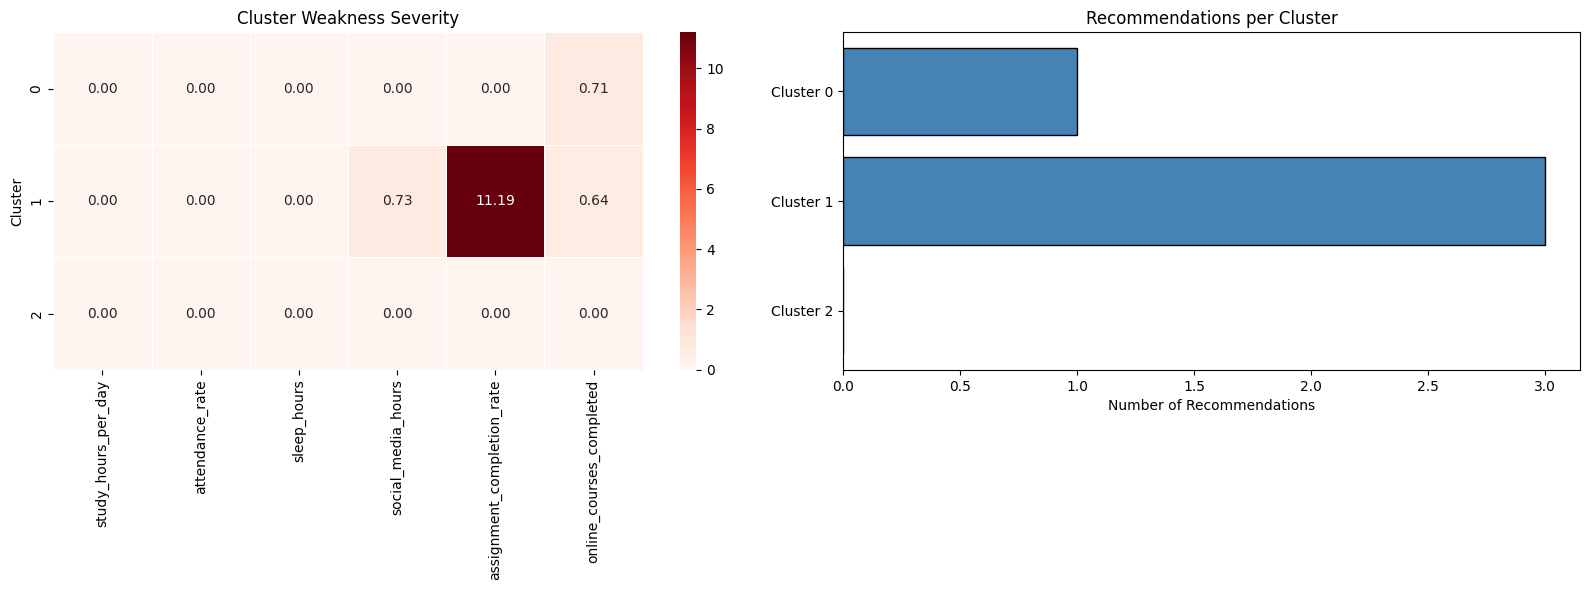

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

weakness_matrix = pd.DataFrame(index=sorted(df['cluster'].unique()),
                                columns=list(behavioral_benchmarks.keys()))
for cluster_id, analysis in cluster_analysis.items():
    for feat in behavioral_benchmarks:
        if feat in analysis['weaknesses']:
            gap = analysis['weaknesses'][feat]['gap']
            weakness_matrix.loc[cluster_id, feat] = gap
        else:
            weakness_matrix.loc[cluster_id, feat] = 0
weakness_matrix = weakness_matrix.astype(float)

sns.heatmap(weakness_matrix, annot=True, fmt='.2f', cmap='Reds', ax=axes[0], linewidths=0.5)
axes[0].set_title('Cluster Weakness Severity')
axes[0].set_ylabel('Cluster')

rec_counts = {cid: len(recs) for cid, recs in cluster_recommendations.items()}
axes[1].barh(['Cluster ' + str(c) for c in sorted(rec_counts.keys())],
             [rec_counts[c] for c in sorted(rec_counts.keys())],
             color='steelblue', edgecolor='black')
axes[1].set_xlabel('Number of Recommendations')
axes[1].set_title('Recommendations per Cluster')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../deliverables/figures/18_recommendation_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Save Student Recommendations

In [6]:
student_recs = df[['student_id', 'cluster']].copy()
student_recs['num_recommendations'] = student_recs['cluster'].map(
    {cid: len(recs) for cid, recs in cluster_recommendations.items()}
)

student_recs.to_csv('../datasets/student_recommendations.csv', index=False)
print(f"Recommendations generated for {len(student_recs)} students")
print(f"Distribution:\n{student_recs['num_recommendations'].value_counts().sort_index()}")

Recommendations generated for 10000 students
Distribution:
num_recommendations
0    2718
1    4008
3    3274
Name: count, dtype: int64
